# ECC4200 Visual Computing and Machine Perception Project #1

In this project, you are going to start an exciting journey to explore Deep Learning and Neural Networks by completing the following three tasks:

* **Task 1. Understanding and conducting convolution (8%).**
* **Task 2. Building and training a ResNet18 model (52%).**
* **Task 3. Exploring and explaining the trained model (40%).**

Before doing the project, please read the instructions carefully (failure to do so will be penalized):

1. Implement your codes **within** "TODO" and "END OF YOUR CODE", do **NOT** modify any codes outside the answer area;
2. Make sure your codes **clean**, **easily readable** (add meaningful comments if needed), and **runnable**;
3. Write your answers in the given markdown cells, keep your answers clear and concise;
4. Do submit your project before the deadline: **31 March, 23:59 SGT (Singapore Time)**. The deadline is strict. **Late submission will be deducted 10 points (out of 100) for every 24 hours**;
5. Once you finish the tasks, **compress the finished notebook (.ipynb file) and the saved model (model_resnet18.pt file) into a zip file**, and then **submit the zip file named as "StudentID_Name_ECC4200_project1.zip"**. Make sure that the **submitted notebook has been run** and the **cell outputs are visible**;
6. This is an individual project, do **NOT** share your solutions with others, we have zero tolerance for cheating.

Note:

1. It is recommended to do model training on GPU, you may use [Colab](https://colab.google/) or [Kaggle](https://www.kaggle.com/) for free computing resources for faster training.
2. Since free computing resources accessible on [Colab](https://colab.google/) is limited for unsuscribed users for each day, it is recommended to debug on your CPU first.

## Task 1: Understanding and conducting convolution (8%)
**Subtasks**
1. Use numpy to conduct 2D standard convolution operation (4%).
2. Use numpy to conduct 2D dilated convolution operation (4%).

You may refer to *["A guide to convolution arithmetic for deeplearning"](https://arxiv.org/pdf/1603.07285.pdf)* for details of dilated convolution.

In this task, we follow the settings as in the paper:
* 2-D discrete convolutions,
* square inputs,
* square kernel size,
* same strides along both axes,
* same zero padding along both axes.

Score points:
1. The implementations are correct.
2. The implementation of dilated convolution makes use of the relationship between dilated convolution kernel and standard convolution kernel.

In [1]:
import numpy as np

In [2]:
def conv2d(inputs,kernels,padding=0, stride=1):
    assert inputs.shape[0] == kernels.shape[1], "The numbers of channels of input and kernel do not match."
    ##############################################################################
    # TODO: conduct convolution calculation based on given inputs, kernels,      #
    #       padding and stride values.                                           #
    ##############################################################################
    # your code
    input_height, input_width = inputs.shape[-2], inputs.shape[-1]
    kernel_size = kernels.shape[-1]
    output_size = (input_height - kernel_size + 2 * padding) // stride + 1
    
    padded_inputs = np.pad(inputs, ((0, 0), (padding, padding), (padding, padding)), mode='constant')
    
    outputs = np.zeros((kernels.shape[0], output_size, output_size))
    print(padded_inputs.shape)
    for i in range(output_size):
        for j in range(output_size):
            region = padded_inputs[:, i * stride:i * stride + kernel_size, j * stride:j * stride + kernel_size]
            # print(region.shape, kernels.shape)
            # print((region * kernels).shape)
            # print(np.sum(region * kernels, axis=(1, 2, 3)).shape)
            outputs[:, i, j] = np.sum(region * kernels, axis=(1, 2, 3))

    ##############################################################################
    #                             END OF YOUR CODE                               #
    ##############################################################################

    return outputs


In [3]:
def dilated_conv2d(inputs,kernels,dilation,padding=0,stride=1):
    assert inputs.shape[0] == kernels.shape[1], "The numbers of channels of input and kernel do not match."
    ##############################################################################
    # TODO: conduct dilated convolution calculation based on given inputs,       #
    #       kernels, padding and stride values.                                  #
    ##############################################################################
    # your code
    input_height, input_width = inputs.shape[-2], inputs.shape[-1]
    kernel_size = kernels.shape[-1]
    dilated_kernel_size = (kernel_size - 1) * (dilation - 1) + kernel_size
    output_size = (input_height - dilated_kernel_size + 2 * padding) // stride + 1
    
    # print(inputs.shape)
    # Padding the input
    padded_inputs = np.pad(inputs, ((0, 0), (padding, padding), (padding, padding)), mode='constant')
    
    outputs = np.zeros((kernels.shape[0], output_size, output_size))
    
    for i in range(output_size):
        for j in range(output_size):
            region = padded_inputs[:, i * stride * dilation:i * stride * dilation + dilated_kernel_size:dilation, 
                                    j * stride * dilation:j * stride * dilation + dilated_kernel_size:dilation]
            outputs[:, i, j] = np.sum(region * kernels, axis=(1, 2, 3))
    
    ##############################################################################
    #                             END OF YOUR CODE                               #
    ##############################################################################

    return outputs

In [4]:
np.random.seed(2024)
inputs = np.random.randint(0,3,size=(2,5,5))
kernels = np.random.randint(0,3,size=(3,2,2,2))
print(f"Inputs:\n{inputs}\n")
print(f"Kernels:\n{kernels}")

Inputs:
[[[0 2 0 0 0]
  [2 1 1 0 2]
  [2 0 1 0 1]
  [2 2 2 0 2]
  [2 1 2 2 0]]

 [[2 1 2 2 1]
  [1 1 2 0 1]
  [2 2 2 0 2]
  [0 2 1 2 2]
  [0 0 1 2 1]]]

Kernels:
[[[[0 0]
   [1 2]]

  [[2 0]
   [2 0]]]


 [[[1 1]
   [2 2]]

  [[0 0]
   [0 1]]]


 [[[1 0]
   [1 1]]

  [[1 1]
   [0 0]]]]


In [5]:
# visualize inputs
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 5))
for i in range(inputs.shape[0]):
    ax = fig.add_subplot(1, inputs.shape[0], i+1, xticks=[], yticks=[])
    ax.set_title('Input channel %s' % str(i+1))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True)
    width = inputs[i].shape[0]
    height = inputs[i].shape[1]


    ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=width))
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=height))
    for x in range(width):
        for y in range(height):
            ax.annotate(str(inputs[i][x][y]), xy=(y/height+(0.5/height),x/width+(0.5/height)),
                        horizontalalignment='center',
                        verticalalignment='center')


In [6]:
# visualize kernels
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 12))
for i in range(kernels.shape[0]):
    for j in range(kernels.shape[1]):
        ax = fig.add_subplot(kernels.shape[0], kernels.shape[1], i*kernels.shape[1] + j+1, xticks=[], yticks=[])
        ax.set_title(f'kernel {str(i+1)}, channel {str(j+1)}')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True)
        width = kernels[i][j].shape[0]
        height = kernels[i][j].shape[1]


        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=width))
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=height))
        for x in range(width):
            for y in range(height):
                ax.annotate(str(kernels[i][j][x][y]), xy=(y/height+(0.5/height),x/width+(0.5/height)),
                            horizontalalignment='center',
                            verticalalignment='center')

In [7]:
conv2d(inputs,kernels,stride=1)

(2, 5, 5)


array([[[10.,  7.,  9.,  8.],
        [ 8.,  8.,  9.,  2.],
        [10., 14.,  8.,  8.],
        [ 4.,  9., 10., 10.]],

       [[ 9.,  8.,  2.,  5.],
        [ 9.,  6.,  3.,  6.],
        [12., 10.,  7.,  7.],
        [10., 11., 12.,  7.]],

       [[ 6.,  7.,  5.,  5.],
        [ 6.,  5.,  4.,  2.],
        [10.,  8.,  5.,  4.],
        [ 7.,  8.,  9.,  6.]]])

In [8]:
dilated_conv2d(inputs,kernels,dilation=2)

array([[[12., 11.,  9.],
        [10.,  8.,  6.],
        [ 6.,  6.,  4.]],

       [[ 8.,  6.,  6.],
        [12.,  7.,  3.],
        [13.,  7.,  1.]],

       [[ 7.,  5.,  4.],
        [10.,  7.,  5.],
        [ 7.,  6.,  2.]]])

## Task 2: Building and training a ResNet18 model (52%)
**Subtasks**
1. Figure out the ResNet18 model architecture and write down the dimension of features of each layer (4%).
2. Build a ResNet18 model by PyTorch (20%).
3. Complete the codes to evaluate and train the model. (10%)
4. Viusalize the training curves (2%).
5. Point out a potential problem in the training process (2%), propose possible solutions (4%) to improve and implement **at least ONE** of them (10%).

Score points:
1. The results for subtask 1 is correct.
2. The implementation for subtask 2 is correct.
3. The implementation for subtask 2 is also concise, i.e., building the network block by block instead of layer by layer.
4.
5. The two plots for visualization contain all information of interest, one for loss curves and another for accuracy curves.
6. The answers to subtask 5 are reasonable and the implementation is correct.


### Prepare packages and dataset

In [9]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
import time

d:\Project\Anaconda\envs\d2l\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_set = torchvision.datasets.CIFAR10(root='D:\\Software\\Python\\Data', train=True,
                                        download=True, transform=transform)

test_set = torchvision.datasets.CIFAR10(root='D:\\Software\\Python\\Data', train=False,
                                       download=True, transform=transform)

train_size = len(train_set)
print(train_size)
test_size = len(test_set)
print(test_size)

Files already downloaded and verified
Files already downloaded and verified
50000
10000


### Define the ResNet18 model

Residual Network (ResNet) is a deep learning model widely used for computer vision applications. It is a Convolutional Neural Network (CNN) architecture. ResNet provides an innovative solution to the vanishing gradient problem, known as “residual connections”.

ResNet includes multiple "residual blocks", each of which contains certain types of layers and residual connections as shown in the figure below.

Refer to the paper *["Deep Residual Learning for Image Recognition"](https://arxiv.org/pdf/1512.03385.pdf)* for information about ResNet architecture.

Figure out the architecture of ResNet18 and the feature dimension of each layer, considering the input dimension as `(3,32,32)` representing `(C, H, W)`. Write down the architecture and the feature dimension corresponding to each layer in the following markdown cell.

Implement to define a ResNet18 model in the following code block.

Note that while doing residual connection, if the dimensions of the input and output of the residual block are not the same, we adjust channels and resolution of the input by means of a convolution before adding.

![](resnet-block.svg)




---
**Write down your results of the ResNet18 architecture and specify the feature dimension for each layer.**

```

```

---

In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, input_channels, num_channels,
                 strides=1):
        '''
        input_channels: the number of channels of input x.
        num_channels: the number of channels channels of the output of the residual block.
        strides: the strides for the first convolutional layer in the residual block, 
                 note that this is not applied to the second convolutional layer in the residual block.
        '''
        ##############################################################################
        # TO DO: Define a ResidualBlock module as the figure shown above.            #
        ##############################################################################
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels, kernel_size=3, stride=strides, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.conv2 = nn.Conv2d(num_channels, num_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(num_channels)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if strides != 1 or input_channels != num_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(input_channels, num_channels, kernel_size=1, stride=strides, bias=False),
                nn.BatchNorm2d(num_channels)
            )
        ##############################################################################
        #                             END OF YOUR CODE                               #
        ##############################################################################


    def forward(self, x):
        ##############################################################################
        # TO DO: implement the forward path of the ResidualBlock module.             #
        ##############################################################################
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out
        ##############################################################################
        #                             END OF YOUR CODE                               #
        ##############################################################################

In [12]:
class ResNet18(nn.Module):
    ##############################################################################
    # TO DO: Define a ResNet18 model and implement its forward path, you may     #
    #        also add other functions to this class if necessary.                #
    ##############################################################################
    # your code
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self.make_layer(64, 64, 2, stride=1)
        self.layer2 = self.make_layer(64, 128, 2, stride=2)
        self.layer3 = self.make_layer(128, 256, 2, stride=2)
        self.layer4 = self.make_layer(256, 512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
        
    def make_layer(self, input_channels, num_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(ResidualBlock(input_channels, num_channels, stride))
            input_channels = num_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # print(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x
        
    ##############################################################################
    #                             END OF YOUR CODE                               #
    ##############################################################################

In [13]:
model = ResNet18()
model

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

### Train the model

In [14]:
# Hyperparameters
epochs = 10
batch_size = 256
learning_rate = 0.1

# Set up optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Define loss function
criterion = torch.nn.CrossEntropyLoss()

# Build data loaders
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)
data_loaders = {"train": train_loader, "test": test_loader}
dataset_sizes = {"train": train_size, "test": test_size}

Write a functions to evaluate the model on testing set and train the model for one epoch in the following code block.

In [15]:
def eval_on_test_set(model):
    model.eval()
    device = torch.cuda.current_device() if torch.cuda.is_available() else "cpu"
    model.to(device)
    running_accuracy = 0
    loss=0

    for data in test_loader:
        ##############################################################################
        # TODO: Implement the evaluation process on test set.                        #
        ##############################################################################
        # your code
        with torch.no_grad():
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss += criterion(outputs, labels).item() * inputs.size(0)
            # print(outputs, labels, loss)
            _, preds = torch.max(outputs, 1)
            running_accuracy += torch.sum(preds == labels.data)
        ##############################################################################
        #                             END OF YOUR CODE                               #
        ##############################################################################
    total_loss=loss/test_size
    total_accuracy = running_accuracy / test_size
    print('Evaluation  on test set: loss{:.3f} \t accuracy = {:.2f}%'.format(total_loss, total_accuracy * 100))
    model.train()
    return total_loss, total_accuracy

In [16]:
def train_for_one_epoch(model):
    model.train()
    # Set up device
    device = torch.cuda.current_device() if torch.cuda.is_available() else "cpu"
    print(f"Using device {device} to train the model.")
    model.to(device)

    # set the running quatities to zero at the beginning of the epoch
    running_loss = 0
    running_accuracy = 0

    for data in train_loader:
        ##############################################################################
        # TODO: Implement the training process for one epoch.                        #
        ##############################################################################
        # your code
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_accuracy += torch.sum(preds == labels.data)

        ##############################################################################
        #                             END OF YOUR CODE                               #
        ##############################################################################

    # Compute stats for the full training set
    total_loss = running_loss / train_size
    total_accuracy = running_accuracy / train_size

    return total_loss, total_accuracy

In [17]:
# start training

metrics = {"train_loss":[], "train_acc":[], "test_loss":[], "test_acc":[]}
for epoch in range(epochs):
  start=time.time()
  train_loss_epoch, train_acc_epoch = train_for_one_epoch(model)
  elapsed = (time.time()-start) / 60
  print('Training epoch= {} \t cost_time= {:.2f} min \t loss= {:.3f} \t accuracy= {:.2f}%'.format(epoch, elapsed, train_loss_epoch, train_acc_epoch * 100))
  test_loss_epoch, test_acc_epoch = eval_on_test_set(model)
  metrics['train_loss'].append(train_loss_epoch)
  metrics['train_acc'].append(train_acc_epoch)
  metrics['test_loss'].append(test_loss_epoch)
  metrics['test_acc'].append(test_acc_epoch)

# save your trained model for the following question
torch.save(model.state_dict(), './model_resnet18.pt')

Using device 0 to train the model.


Training epoch= 0 	 cost_time= 0.26 min 	 loss= 1.649 	 accuracy= 43.62%
Evaluation  on test set: loss1.447 	 accuracy = 50.55%
Using device 0 to train the model.
Training epoch= 1 	 cost_time= 0.21 min 	 loss= 1.099 	 accuracy= 61.35%
Evaluation  on test set: loss37.985 	 accuracy = 16.97%
Using device 0 to train the model.
Training epoch= 2 	 cost_time= 0.21 min 	 loss= 0.917 	 accuracy= 68.09%
Evaluation  on test set: loss1.065 	 accuracy = 63.17%
Using device 0 to train the model.
Training epoch= 3 	 cost_time= 0.21 min 	 loss= 0.736 	 accuracy= 74.23%
Evaluation  on test set: loss1.179 	 accuracy = 61.96%
Using device 0 to train the model.
Training epoch= 4 	 cost_time= 0.18 min 	 loss= 0.608 	 accuracy= 78.60%
Evaluation  on test set: loss1.409 	 accuracy = 57.98%
Using device 0 to train the model.
Training epoch= 5 	 cost_time= 0.19 min 	 loss= 0.510 	 accuracy= 82.08%
Evaluation  on test set: loss0.967 	 accuracy = 68.97%
Using device 0 to train the model.
Training epoch= 6 	 c

Visualize the training curves for loss and accuracy in the following code block. Your figure should include two subplots, one for loss curves on training and testing sets, and another for accuracy curves on training and testing sets.

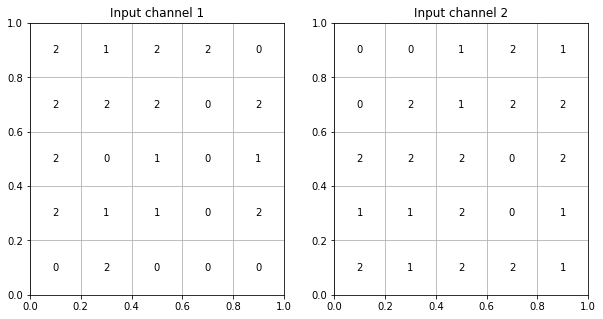

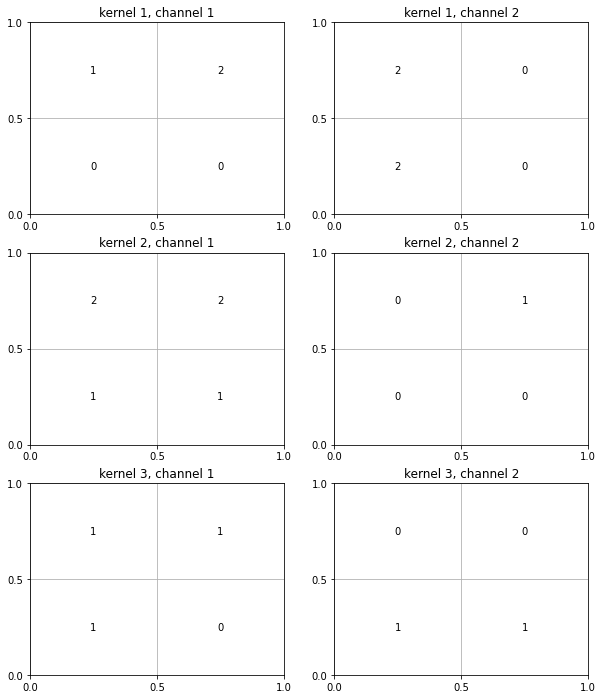

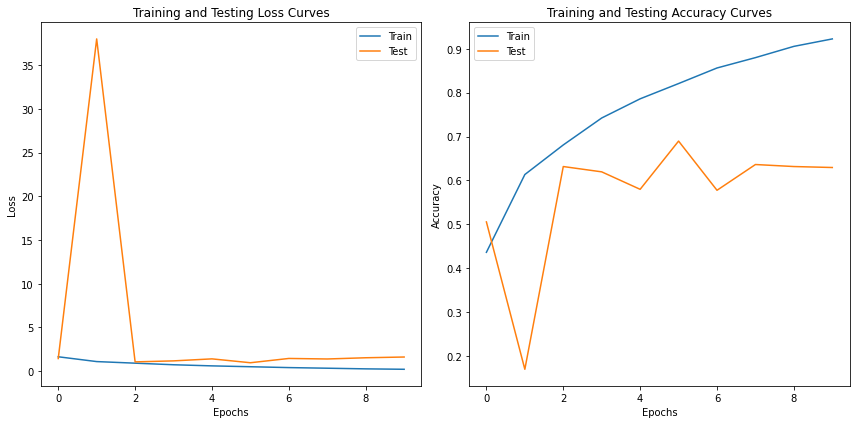

In [18]:
###############################################################################
# TODO: Visualize the loss curves and accuracy curves on training and         #
#       testing sets respectively during training.                            #
###############################################################################

# your code
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(epochs), metrics['train_loss'], label='Train')
plt.plot(range(epochs), metrics['test_loss'], label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Testing Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(epochs), metrics['train_acc'], label='Train')
plt.plot(range(epochs), metrics['test_acc'], label='Test')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Testing Accuracy Curves')
plt.legend()

plt.tight_layout()
plt.show()

##############################################################################
#                             END OF YOUR CODE                               #
##############################################################################

### Improve the ResNet18 trained above


Observe the loss and accuracy curves during training and testing respectively, what potential problem can be concluded if continue training the model for further epochs most probably? What kind of techniques can be applied to solve this problem?

---
**Write your observations and analysis in this Markdown cell:**


```

The model seems to gonna be overfitting.

The loss in training is really low, while the test loss is still pretty high.

The best solution for overfitting is to get bigger dataset.

Also, we can add regularzation methods, like dropout.
```


---

Please choose one technique you mentioned above and implement it, retrain the model, observe and report the loss and accuracy again (10%).

**Note: you are not expected to save your improved model with the name "model_resnet18.pt" in this part.**

In [19]:
##############################################################################
# TODO: Choose a technique to improve your model.                            #
##############################################################################

# your code
import torch.nn.functional as F

class NewResNet18(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.5):
        super(ResNet18, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self.make_layer(64, 64, 2, stride=1, dropout_rate=dropout_rate)
        self.layer2 = self.make_layer(64, 128, 2, stride=2, dropout_rate=dropout_rate)
        self.layer3 = self.make_layer(128, 256, 2, stride=2, dropout_rate=dropout_rate)
        self.layer4 = self.make_layer(256, 512, 2, stride=2, dropout_rate=dropout_rate)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(dropout_rate)

    def make_layer(self, input_channels, num_channels, num_blocks, stride, dropout_rate):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(ResidualBlock(input_channels, num_channels, stride))
            input_channels = num_channels
        layers.append(nn.Dropout(dropout_rate))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


##############################################################################
#                             END OF YOUR CODE                               #
##############################################################################

---
**Write your observations and analysis in this Markdown cell:**


```
Got a much better performance. The test loss is much closer to train closs.
```
---

## Task 3: Exploring and explaining the trained model (40%)

**Subtasks:**

1. Visualize the representations for bottom and top layers by t-SNE, compare and make conclusion (6%).
2. Compute saliency map and answer the question about it (6%).
3. Compute improved saliency map by SMOOTHGRAD and answer the question about the comparison between the saliency map in subtask 2 and SMOOTHGRAD (10%).
4. Design and conduct experiment to explain how CNN works using SMOOTHGRAD (12%).
5. Given a model, generate fooling image based on an original image and a target label to fool. Write down the observations from the result (6%).

Score points:
1. For subtask 1, recognize the correct layers of insterest, extract corresponding intermediate features and make reasonable conclusion.
2. For subtask 2, the implementation is correct and as concise as possible and the question is correctly answered.
3. For subtask 3, the implementation is correct and as concise as possible and the question is correctly answered.
4. For subtask 4, the experiment is reasonably designed and appropriately conducted.
5. For subtask 5, the implementation is correct and observation is reasonable.

**<mark>Highlightedd Note: for task 3, just use the model trained and saved in task 2 part "define the ResNet18 model" instead of your improved model in task 2 part "improve the ResNet18".<mark>**

### Load the trained ResNet18 model above.

In [20]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.cm as cm
import torch.nn as nn
import os

trained_model = ResNet18()
assert os.path.exists('./model_resnet18.pt'), 'train the model first'
# Load the model trained and saved in task 2 part "define the ResNet18 model" 
trained_model.load_state_dict(torch.load('./model_resnet18.pt', map_location=torch.device('cpu'))) 

device = torch.cuda.current_device() if torch.cuda.is_available() else 'cpu'
trained_model.to(device)
trained_model.eval()

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

### Visualize the learned features for the trained ResNet18 of different layers of model.

t-SNE (t-distributed Stochastic Neighbor Embedding) is an unsupervised non-linear dimensionality reduction technique for data exploration and visualizing high-dimensional data. Here, you shall apply t-SNE to the features extracted from a bottom layer and a top layer of the trained ResNet18 model.

You should complete:
* 1) extract features for the bottom layer and top layer respectively, i.e., the intermediate outputs of these layers.
* 2) if the extracted features are in form of feature maps, reshape the feature map for each sample to make it a vector.
* 3) visualize the features for the bottom and top layers by t-SNE, observe and analyze the results.

The bottom layer is defined as the first max-pooling layer of the whole model; the top layer is defined as the penultimate layer of the whole model. (We refer to the input side as "bottom" and the output side as "top".)

In [35]:
##############################################################################
# TO DO: Extract intermediate features of the top and bottom layers          #
#        based on your ResNet18 model.                                       #
##############################################################################
# your code



def extract_features(model, layer_name, data_loader):
    labels = np.array([])
    features = []
    model.eval()
    with torch.no_grad():
        for inputs, label in data_loader:
            if inputs.shape[0] != 256:
                continue
            labels = np.concatenate((labels, label))
            inputs = inputs.to(device)
            output = model.maxpool(model.relu(model.bn1(model.conv1(inputs))))
            if layer_name == 'bottom':
                # print(inputs.shape)
                features.append(output.cpu().numpy())
                continue
            elif layer_name == 'top':
                # print(inputs.shape)
                output = model.layer4(model.layer3(model.layer2(model.layer1(output))))
                output = model.avgpool(output)
                features.append(output.cpu().numpy())
    return np.concatenate(features, axis=0), labels



features_bottom, labels = extract_features(model, 'bottom', test_loader)
labels = labels.astype(np.int32)
features_bottom = features_bottom.reshape(-1, 4096)
# print(type(features_bottom))

features_top, labels = extract_features(model, 'top', test_loader)
features_top = features_top.reshape(-1, 512)

##############################################################################
#                             END OF YOUR CODE                               #
##############################################################################

features_top = np.array(features_top) # (10000,512)
print(features_top.shape)
features_bottom = np.array(features_bottom) # (10000,4096)
print(features_bottom.shape)
colors_per_class = cm.rainbow(np.linspace(0, 1, 11))

# Apply t-SNE to the features
features_top_tsne = TSNE(n_components=2, init='pca', random_state=42).fit_transform(features_top)
features_bottom_tsne = TSNE(n_components=2, init='pca', random_state=42).fit_transform(features_bottom)

# Plot the t-SNE visualization
plt.figure(figsize=(20, 8))

plt.subplot(1,2,1)
plt.title('Bottom Layer')
for label in np.unique(labels):
    plt.scatter(features_bottom_tsne[labels == label, 0], features_bottom_tsne[labels == label, 1], label=classes[label], s=5)
plt.legend()
plt.subplot(1,2,2)
plt.title('Top Layer')
for label in np.unique(labels):
    plt.scatter(features_top_tsne[labels == label, 0], features_top_tsne[labels == label, 1], label=classes[label], s=5)
plt.legend()
plt.gcf().tight_layout()

plt.show()

(9984, 512)
(9984, 4096)


TypeError: tuple indices must be integers or slices, not numpy.float64

(9984,)
(9984, 2)


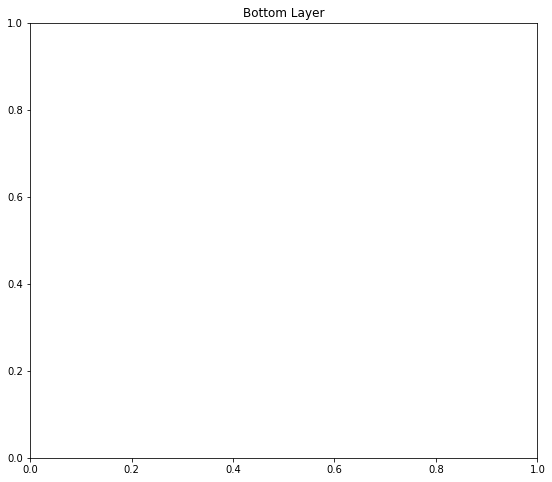

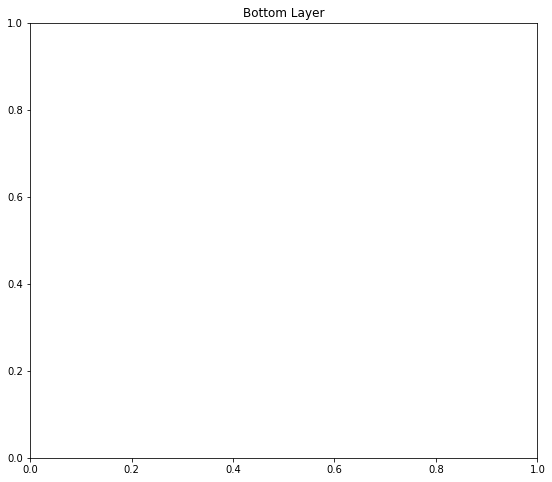

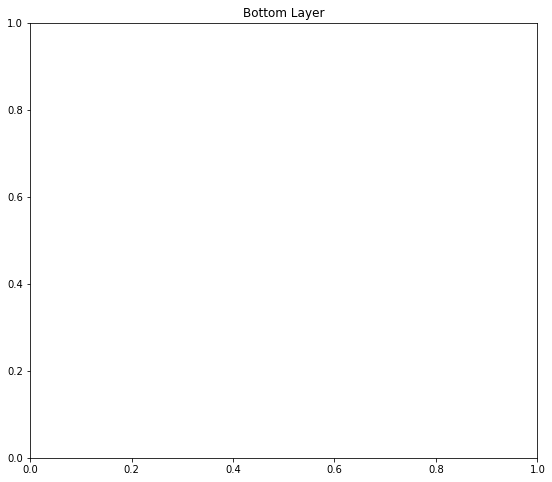

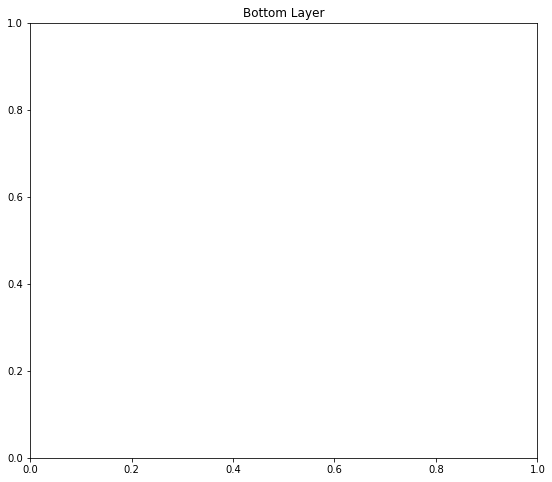

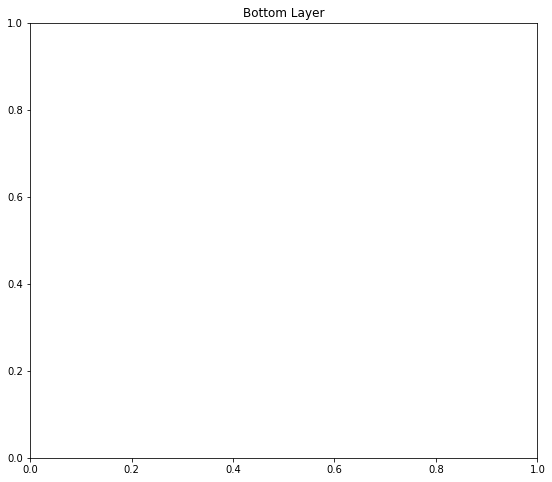

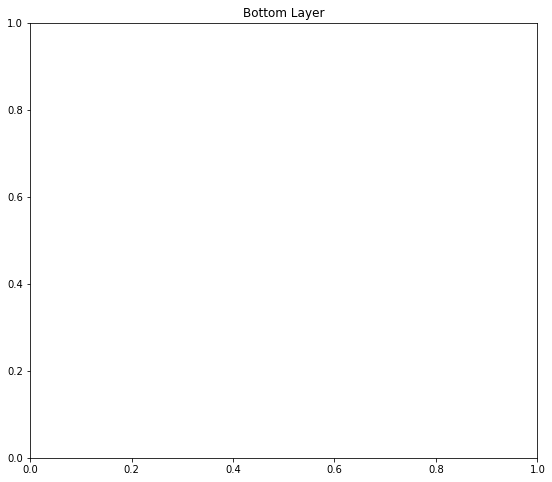

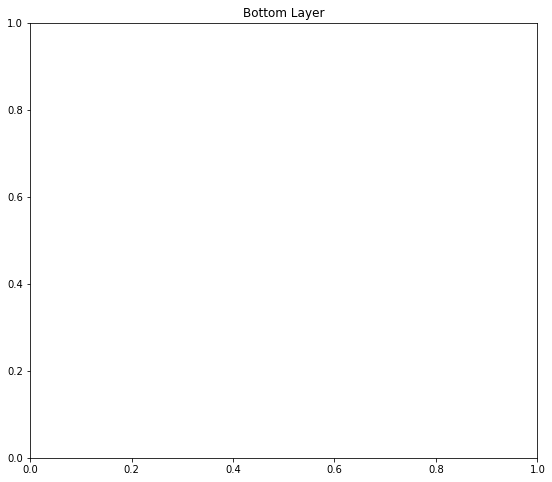

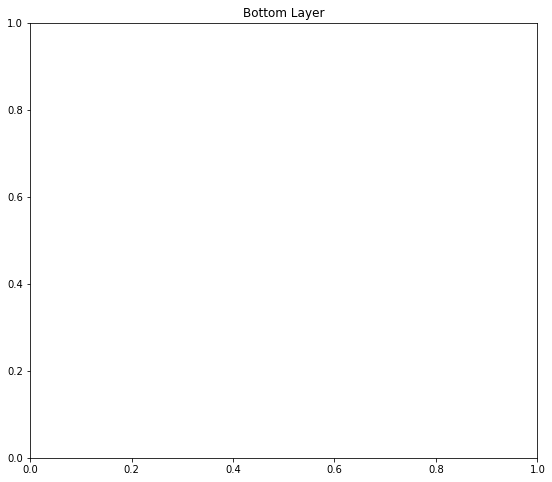

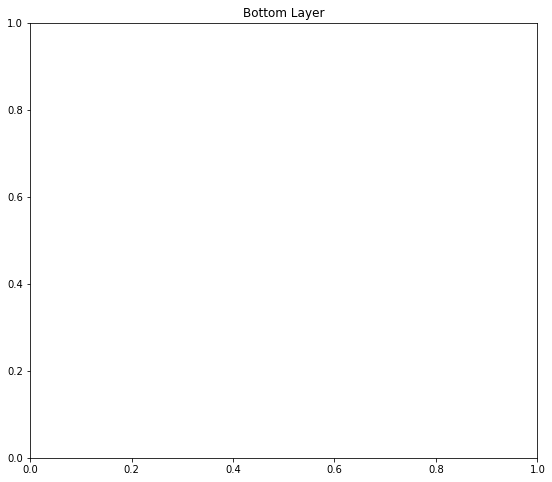

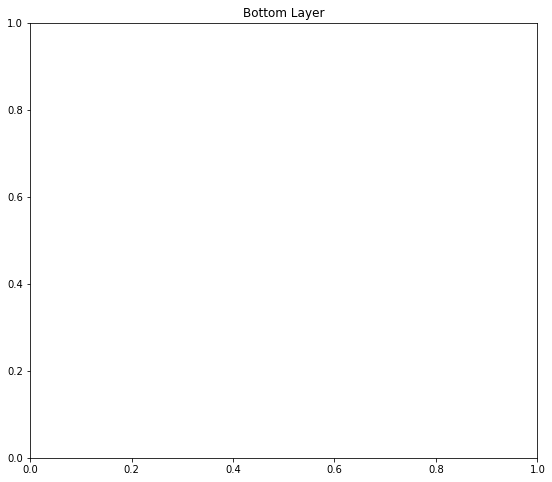

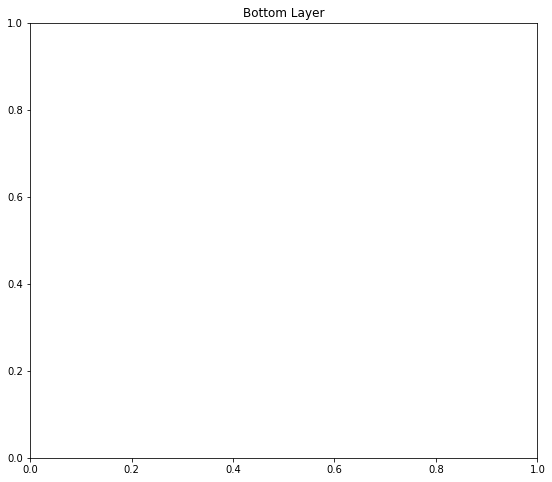

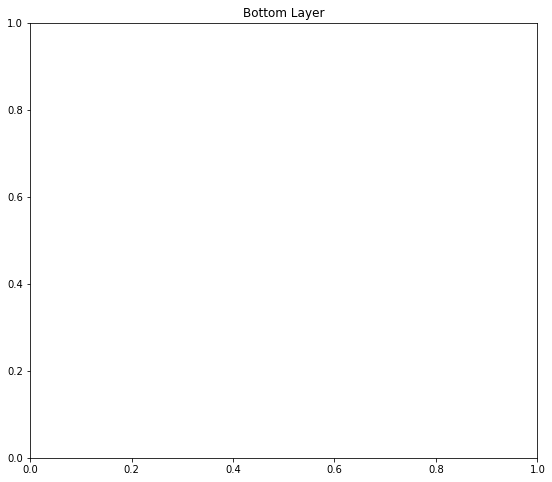

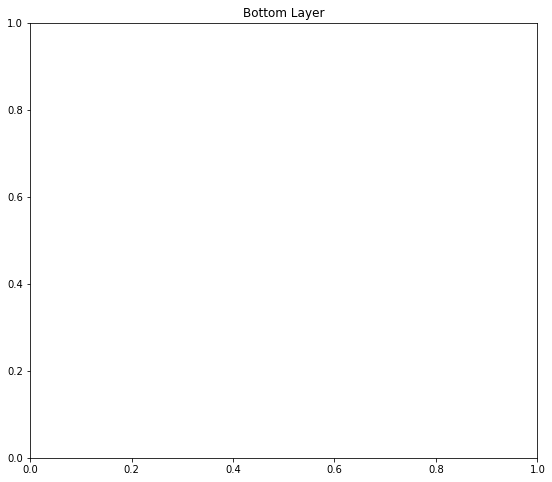

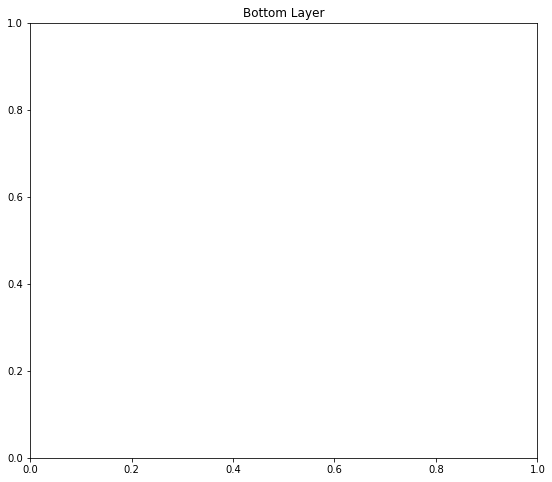

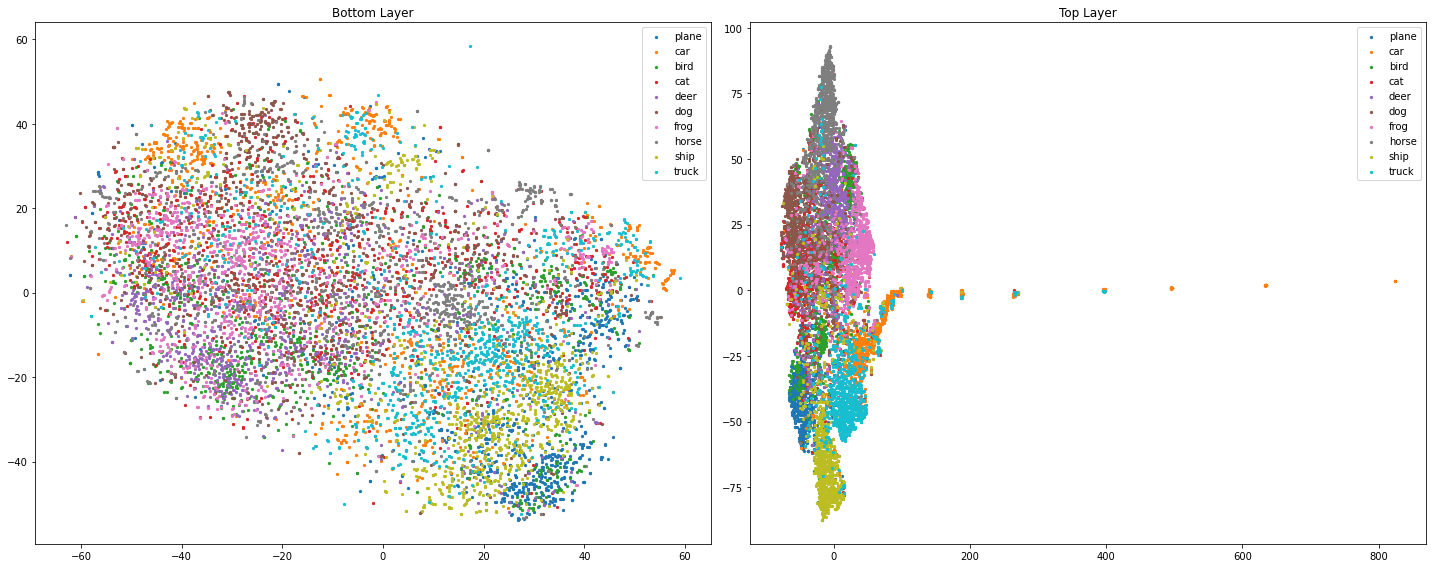

In [40]:
print(labels.shape)
print(features_bottom_tsne.shape)
labels = labels.astype(np.int32)
# Plot the t-SNE visualization
plt.figure(figsize=(20, 8))

plt.subplot(1,2,1)
plt.title('Bottom Layer')
for label in np.unique(labels):
    # print(labels == label)
    plt.scatter(features_bottom_tsne[labels == label, 0], features_bottom_tsne[labels == label, 1], label=classes[label], s=5)
plt.legend()
plt.subplot(1,2,2)
plt.title('Top Layer')
for label in np.unique(labels):
    plt.scatter(features_top_tsne[labels == label, 0], features_top_tsne[labels == label, 1], label=classes[label], s=5)
plt.legend()
plt.gcf().tight_layout()

plt.show()

---
**Write your observations and analysis in this Markdown cell:**

```
Samples of the same label are more tightly clustered

Which indicates that the network is able to classify sample according to their feature.
```

---

### Compute saliency map.

A saliency map tells us the degree to which each pixel in the image affects the classification score for that image. To compute it, we compute the gradient of the unnormalized score corresponding to the correct class (which is a scalar) with respect to the pixels of the image.

Read and understand the paper below, figure out how to compute saliency maps and implement it in the `compute_saliency_maps` function.

[Karen Simonyan, Andrea Vedaldi, and Andrew Zisserman. "Deep Inside Convolutional Networks: Visualising Image Classification Models and Saliency Maps", ICLR Workshop 2014.](https://arxiv.org/pdf/1312.6034.pdf)

In [41]:
### helper function

def show_saliency_maps(X, y, saliency):
    # Compute saliency maps for images in X

    # Convert the saliency map from Torch Tensor to numpy array and show images
    # and saliency maps together.
    if saliency.dim() == 4:
      saliency = saliency.permute(0, 2, 3, 1).numpy()
    elif saliency.dim() == 3:
      saliency = saliency.numpy()
    N = X.shape[0]
    for i in range(N):
        plt.subplot(2, N, i + 1)
        img = np.transpose((X.detach()/2+0.5).numpy(),(0,2,3,1))
        plt.imshow(img[i])
        plt.axis('off')
        plt.title(classes[y.detach().numpy()[i]])
        plt.subplot(2, N, N + i + 1)
        plt.imshow(saliency[i], cmap=plt.cm.hot)
        plt.axis('off')
        plt.gcf().set_size_inches(12, 5)
    plt.show()


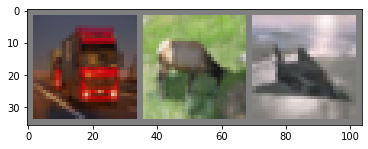

truck	deer 	plane


In [42]:
### example images for saliency map and SmoothGrad visualization

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(test_loader)
images,labels = next(dataiter)
X = images[-3:,:,:,:]
y = labels[-3:]

# show images
imshow(torchvision.utils.make_grid(X))
print('\t'.join(f'{classes[y[j]]:5s}' for j in range(3)))

In [64]:
def compute_saliency_maps(X, y, model):
    """
    Compute a class saliency map using the model for images X and labels y.

    Input:
    - X: Input images; Tensor of shape (N, 3, H, W)
    - y: Labels for X; Tensor of shape (N,)
    - model: A pretrained CNN that will be used to compute the saliency map.

    Returns:
    - saliency: A Tensor of shape (N, H, W) giving the saliency maps for the input
    images.
    """
    # Make sure the model is in "test" mode
    model.eval()

    ##############################################################################
    # TODO: Implement this function. Perform a forward and backward pass through #
    # the model to compute the gradient of the correct class score with respect  #
    # to each input image.                                                       #
    ##############################################################################
    # your code

    X.requires_grad_()
    # X = X.to('cpu')
    model = model.to(X.device)

    scores = model(X)
    scores = scores.gather(1, y.view(-1, 1)).squeeze()

    
    scores = scores.to(X.device)
    print(scores.device, X.device)
    scores.backward(torch.ones(scores.size()).to(X.device))


    saliency = X.grad.data


    saliency = saliency.abs()
    saliency, _ = torch.max(saliency, dim=1)
    ##############################################################################
    #                             END OF YOUR CODE                               #
    ##############################################################################
    return saliency

cuda:0 cuda:0


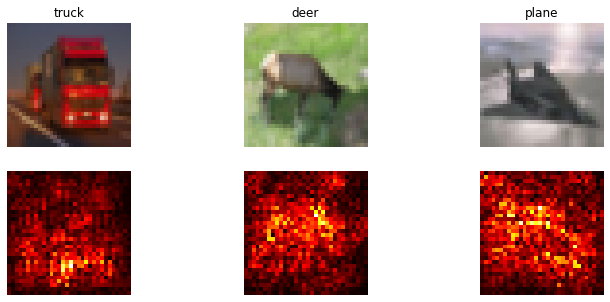

In [65]:
saliency = compute_saliency_maps(X.to(device), y.to(device), trained_model)
show_saliency_maps(X, y, saliency.cpu())

In order to find an image that maximizes the correct score, we can perform gradient ascent on the input image, can we use the saliency map instead of the gradient we in each step to update the image. Is this assertion true? Why or why not?

---
**Write your answer and reason in this Markdown cell.**

---

```
Of course not. The salicency map only indicates the result of gradient ascent. 
Or we can consider in this way: We you calculate the saliency map, you don't introduce ground truth information. Which means that it's impossible to use saliency map to update the image.
```

### Obtain improved visualiztion results by SmoothGrad.

SmoothGrad is a method that can help visually sharpen gradient-based saliency maps thus improve the visulization quality. *["SmoothGrad: removing noise by adding noise", ICML2017.](https://arxiv.org/pdf/1706.03825.pdf)*


Read and understand the paper, implement SmoothGrad and apply **at least ONE** visualization technique mentioned in the paper in the following code block to get better results.

You may also refer to this [blog](https://medium.com/@ML-STATS/reducing-noise-and-improving-interpretability-in-cnns-a-technical-review-of-the-smoothgrad-method-da648ee830c6) for concise illustration for SmoothGrad.


In [66]:
from torch.autograd import Variable
def compute_smoothgrad(X, y, model, num_samples=50, stdev_spread=0.15):
    """
    Compute smoothed gradients for images in X given model

    Inputs:
    - X: Input images; Tensor of shape (N, 3, H, W)
    - y: Labels for X; Tensor of shape (N,)
    - model: A pretrained CNN that will be used to compute gradients; see
      the torchvision library
    - num_samples: An integer; the number of gradient samples to compute for each
      input in X.
    - stdev_spread: A float; the standard deviation of the Gaussians used to
      smooth the gradients.

    Returns:
    - smoothgrad: saliency: A Tensor of shape (N, 3, H, W) giving the smoothed saliency maps for the input
    images.
    """

    # Make sure the model is in "test" mode
    model.eval()

    ################################################################################
    # TODO: Implement this function. Calculate SmoothGrad (smoothed saliency maps) #
    #       based on the given parameters for this function.                       #
    ################################################################################
    # your code
    smoothgrad = torch.zeros_like(X)

    for i in range(len(X)):
        x = X[i:i+1].clone().detach().requires_grad_(True)
        scores = model(x)
        score = scores[0, y[i]]
        score.backward()

        smoothgrads = torch.zeros_like(x)
        for _ in range(num_samples):
            noisy_x = x + torch.randn_like(x) * stdev_spread
            noisy_scores = model(noisy_x)
            noisy_score = noisy_scores[0, y[i]]
            grad = torch.autograd.grad(noisy_score, noisy_x)[0]
            smoothgrads += grad

        smoothgrads /= num_samples
        smoothgrad[i] = smoothgrads

    ##############################################################################
    #                             END OF YOUR CODE                               #
    ##############################################################################

    smoothgrad = (smoothgrad - smoothgrad.min()) / (smoothgrad.max() - smoothgrad.min()) # just for better visualization
    return smoothgrad



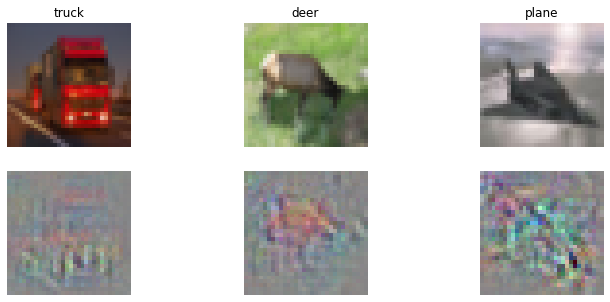

In [67]:
smoothgrad = compute_smoothgrad(X.to(device), y.to(device), trained_model)
show_saliency_maps(X, y, smoothgrad.cpu())

Compare the results of saliency map and SmoothGrad, what is your discovery? Try to understand the papers to give a reason for the phenomenon.

---

**Write your observations and analysis in this Markdown cell:**

---

```
The result in SmoothGrad is much more smooth that scliency map.

The improved robustness and smoothness of saliency maps produced by SmoothGrad can be attributed to its ability to mitigate the effects of noise and perturbations through the process of averaging over multiple gradient samples.
```

### Design and conduct experiment  to explore and explain how CNN works.

Design and conduct one experiment beyond the example images above by utilizing ```compute_smoothgrad```, e.g., compare the SmoothGrad maps of different classes given the same model, compare the SmoothGrad maps of the same class for different models, etc. Please quanlitatively show some evidence (e.g., plotting some examplar images clearly and elegantly) with necessary code snippets, write down your observations and briefly explain.

For the experiment you design, please specify:
1. What question do you intend to study?
2. To study the proposed question, how do you design your experiment?
3. What conclusion do you make from the experiment results?

#### Experiment Target

Investigating the Impact of Image Rotation on CNNs

#### Experiment Design

Compare the SmoothGrad maps between before and after the rotation.

cuda:0 cuda:0
cuda:0 cuda:0
cuda:0 cuda:0


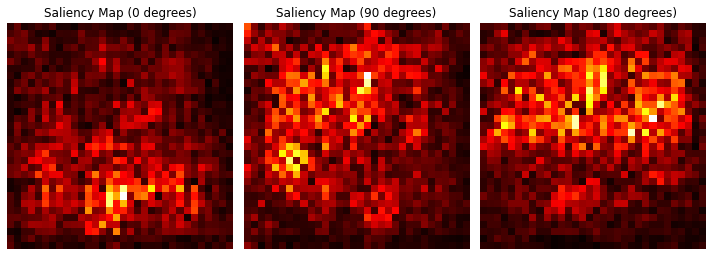

In [69]:
##############################################################################
# TO DO: Design and conduct your experiment.                                 #
##############################################################################
# your code
import torchvision.transforms.functional as TF

def rotate_image(image, angle):
    """Rotate image by given angle."""
    return TF.rotate(image, angle)

def visualize_saliency_maps(X, y, model, angle1, angle2):
    """
    Visualize Saliency Maps before and after rotating the images.

    Inputs:
    - X: Input images; Tensor of shape (N, 3, H, W)
    - y: Labels for X; Tensor of shape (N,)
    - model: A pretrained CNN that will be used to compute the saliency map.
    - angle1: Angle for the first rotation.
    - angle2: Angle for the second rotation.
    """
    model.eval()

    X_rotated1 = rotate_image(X, angle1)
    X_rotated2 = rotate_image(X, angle2)

    saliency0 = compute_saliency_maps(X, y, model)
    saliency1 = compute_saliency_maps(X_rotated1, y, model)
    saliency2 = compute_saliency_maps(X_rotated2, y, model)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(saliency0[0].cpu().numpy(), cmap='hot', interpolation='nearest')
    plt.title('Saliency Map ({} degrees)'.format(0))
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(saliency1[0].cpu().numpy(), cmap='hot', interpolation='nearest')
    plt.title('Saliency Map ({} degrees)'.format(angle1))
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(saliency2[0].cpu().numpy(), cmap='hot', interpolation='nearest')
    plt.title('Saliency Map ({} degrees)'.format(angle2))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

angle1 = 90
angle2 = 180

visualize_saliency_maps(X.to(device), y.to(device), trained_model, angle1, angle2)
##############################################################################
#                             END OF YOUR CODE                               #
##############################################################################

---

**Write your observations and analysis in this Markdown cell:**

---

```
We can easily discover that the SmoothGrad Maps do not rotate as the inputs rotate, i.e. our CNN isn't rotation invarience. Which means that, the perfoemance of our CNN might be influenced if we rotate the input image. However, we can still observe that the bright area do rotate as the inputs rotate, which indicates that our CNN didn't totally lose efficacy.

Note that even for human, rotation of image might bring adverse effects. Therefore I think we can accept the rotation invarience of CNN network.
```

### Fooling image
We can also use image gradients to generate "fooling images", that is, given an image and a target class, we can perform gradient ascent over the image to maximize the target class, stopping when the network classifies the image as the target class. Implement the following function to generate fooling images.

In [70]:
def make_fooling_image(X, target_y, model):
    """
    Generate a fooling image that is close to X, but that the model classifies
    as target_y.

    Inputs:
    - X: Input image; Tensor of shape (1, 3, H, W)
    - target_y: An integer in the range [0, 10)
    - model: A pretrained CNN

    Returns:
    - X_fooling: An image that is close to X, but that is classifed as target_y
    by the model.
    """
    # Initialize our fooling image to the input image, and make it require gradient
    X_fooling = X.clone()
    X_fooling = X_fooling.requires_grad_()

    learning_rate = 1
    ##############################################################################
    # TODO: Generate a fooling image X_fooling that the model will classify as   #
    # the class target_y. You should perform gradient ascent on the score of the #
    # target class, stopping when the model is fooled.                           #
    # When computing an update step, first normalize the gradient:               #
    #   dX = learning_rate * g / ||g||_2                                         #
    #                                                                            #
    # You should write a training loop.                                          #
    #                                                                            #
    # HINT: For most examples, you should be able to generate a fooling image    #
    # in fewer than 100 iterations of gradient ascent.                           #
    # You can print your progress over iterations to check your algorithm.       #
    ##############################################################################
    
    # your code
    max_iter = 100
    confidence_threshold = 0.99

    for i in range(max_iter):
        scores = model(X_fooling)

        target_score = scores[0, target_y]

        if torch.softmax(scores, dim=1)[0, target_y] > confidence_threshold:
            print("Model fooled at iteration", i)
            break

        target_score.backward()

        grad = X_fooling.grad.data
        grad /= grad.norm()

        X_fooling.data += learning_rate * grad

        X_fooling.grad.data.zero_()
    ##############################################################################
    #                             END OF YOUR CODE                               #
    ##############################################################################
    return X_fooling

In [71]:
target_y = 6 # label 'frog'
image_to_be_fooled = images[-1:,:,:,:] # an image of plane
y = labels[-1:] # label 'plane'

X_fooling = make_fooling_image(image_to_be_fooled.to(device), target_y, trained_model.to(device))

scores = trained_model(X_fooling)
assert target_y == scores.data.max(1)[1][0].item(), 'The model is not fooled!'

Model fooled at iteration 3


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
d:\Project\Anaconda\envs\d2l\lib\site-packages\ipykernel_launcher.py:27: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.


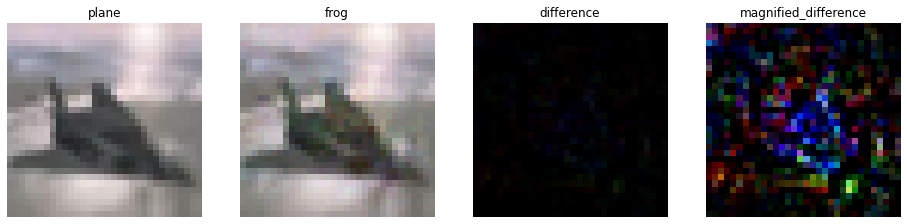

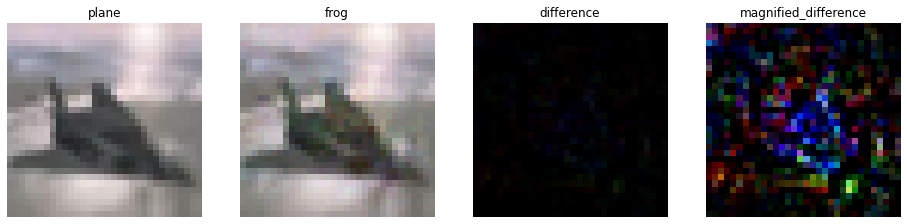

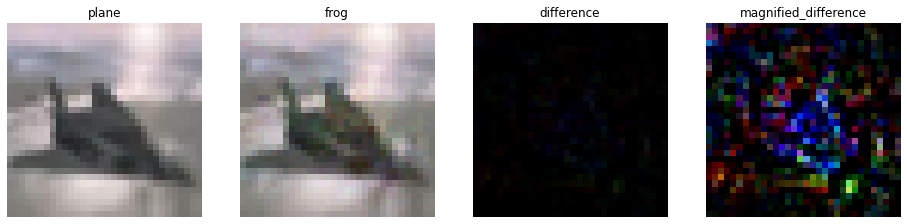

In [74]:
org_img = (torch.squeeze(image_to_be_fooled, dim=0).detach().cpu().numpy()) / 2 + 0.5
fooling_img = (torch.squeeze(X_fooling, dim = 0).detach().cpu().numpy()) / 2 + 0.5

fooling_img.astype(np.uint8)

fig = plt.figure(figsize=(16, 5))
plt.subplot(1, 4, 1)
plt.imshow(org_img.transpose((1, 2, 0)))
plt.title(classes[y])
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(fooling_img.transpose((1, 2, 0)))
plt.title(classes[target_y])
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow((org_img - fooling_img).transpose((1, 2, 0)))
plt.title('difference')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(10*(org_img - fooling_img).transpose((1, 2, 0)))
plt.title('magnified_difference')
plt.axis('off')

# fig.show()
plt.show()

Observe the results above and write down your discovery.

---

**Write your observations and analysis in this Markdown cell:**

---

```
Before and after fooling, the image didn't change too much for human. But for network, it changed a lot.
```